**Работу выполнила Белозерова Ольга**

# **Прогнозирование заработной платы сотрудников**

## **Выбор бейзлайн-модели**

**В качестве бейзлайн-модели выбрана линейная регрессия**, поскольку разведочный анализ данных выявил наличие линейных связей между ключевыми признаками, такими как стаж работы, размер компании и уровень образования, и целевой переменной - годовой зарплатой. Кроме того, эта модель обеспечивает высокую интерпретируемость результатов, позволяя оценить значимость каждого признака через коэффициенты регрессии и понять их вклад в предсказание зарплаты.


## **Выбор признаков для модели**

Загружаем сохранённый датасет с предобработкой, произведенной на этапе EDA

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Загружаем сохранённый датасет
df_final = pd.read_csv("/content/employee_salary_data_clean.csv")

print(f"Размер датасета: {df_final.shape[0]} строк, {df_final.shape[1]} столбцов")

print("\nПервые 5 строк датасета:")
df_final.head()

Размер датасета: 249860 строк, 9 столбцов

Первые 5 строк датасета:


,job_title,experience_years,education_level,skills_count,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Large,Sweden,Yes,0,165069


**Для построения модели решено использовать все оставшиеся после этапа EDA признаки**: с одной стороны, experience_years, company_size, education_level, location и job_title демонстрируют умеренную корреляцию с целевой переменной, что делает их очевидными кандидатами для включения в модель, а с другой стороны, skills_count, certifications и remote_work, хотя и показывают крайне слабую индивидуальную связь с зарплатой, в многомерном пространстве способны вносить значимый вклад в прогноз, взаимодействуя с более сильными факторами. Такой подход позволяет сохранить максимальный объём доступной информации и учесть потенциальные взаимодействия между переменными.

## **Разбиение датасета на train и test выборки**

### **Разбиение датасета на train и test выборки**

In [13]:
from sklearn.model_selection import train_test_split

# Отделяем целевую переменную от признаков
X = df_final.drop('salary', axis=1)
y = df_final['salary']

# Разбиваем на train и test выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)

### **Проверка сопоставимости распределений в тренировочной и тестовой выборках**

**При разбиении датасета на тренировочную и тестовую выборки важно проверить сопоставимость распределений в них**, поскольку если распределения значительно различаются, то модель будет оцениваться на данных, для которых она изначально не была оптимизирована, что приведёт к некорректной оценке её обобщающей способности и создаст ложное впечатление о реальной эффективности. Сопоставимость выборок гарантирует, что тестовые данные отражают структуру генеральной совокупности, с которой модель столкнётся в реальной эксплуатации, а полученные метрики качества объективно характеризуют её способность к обобщению.

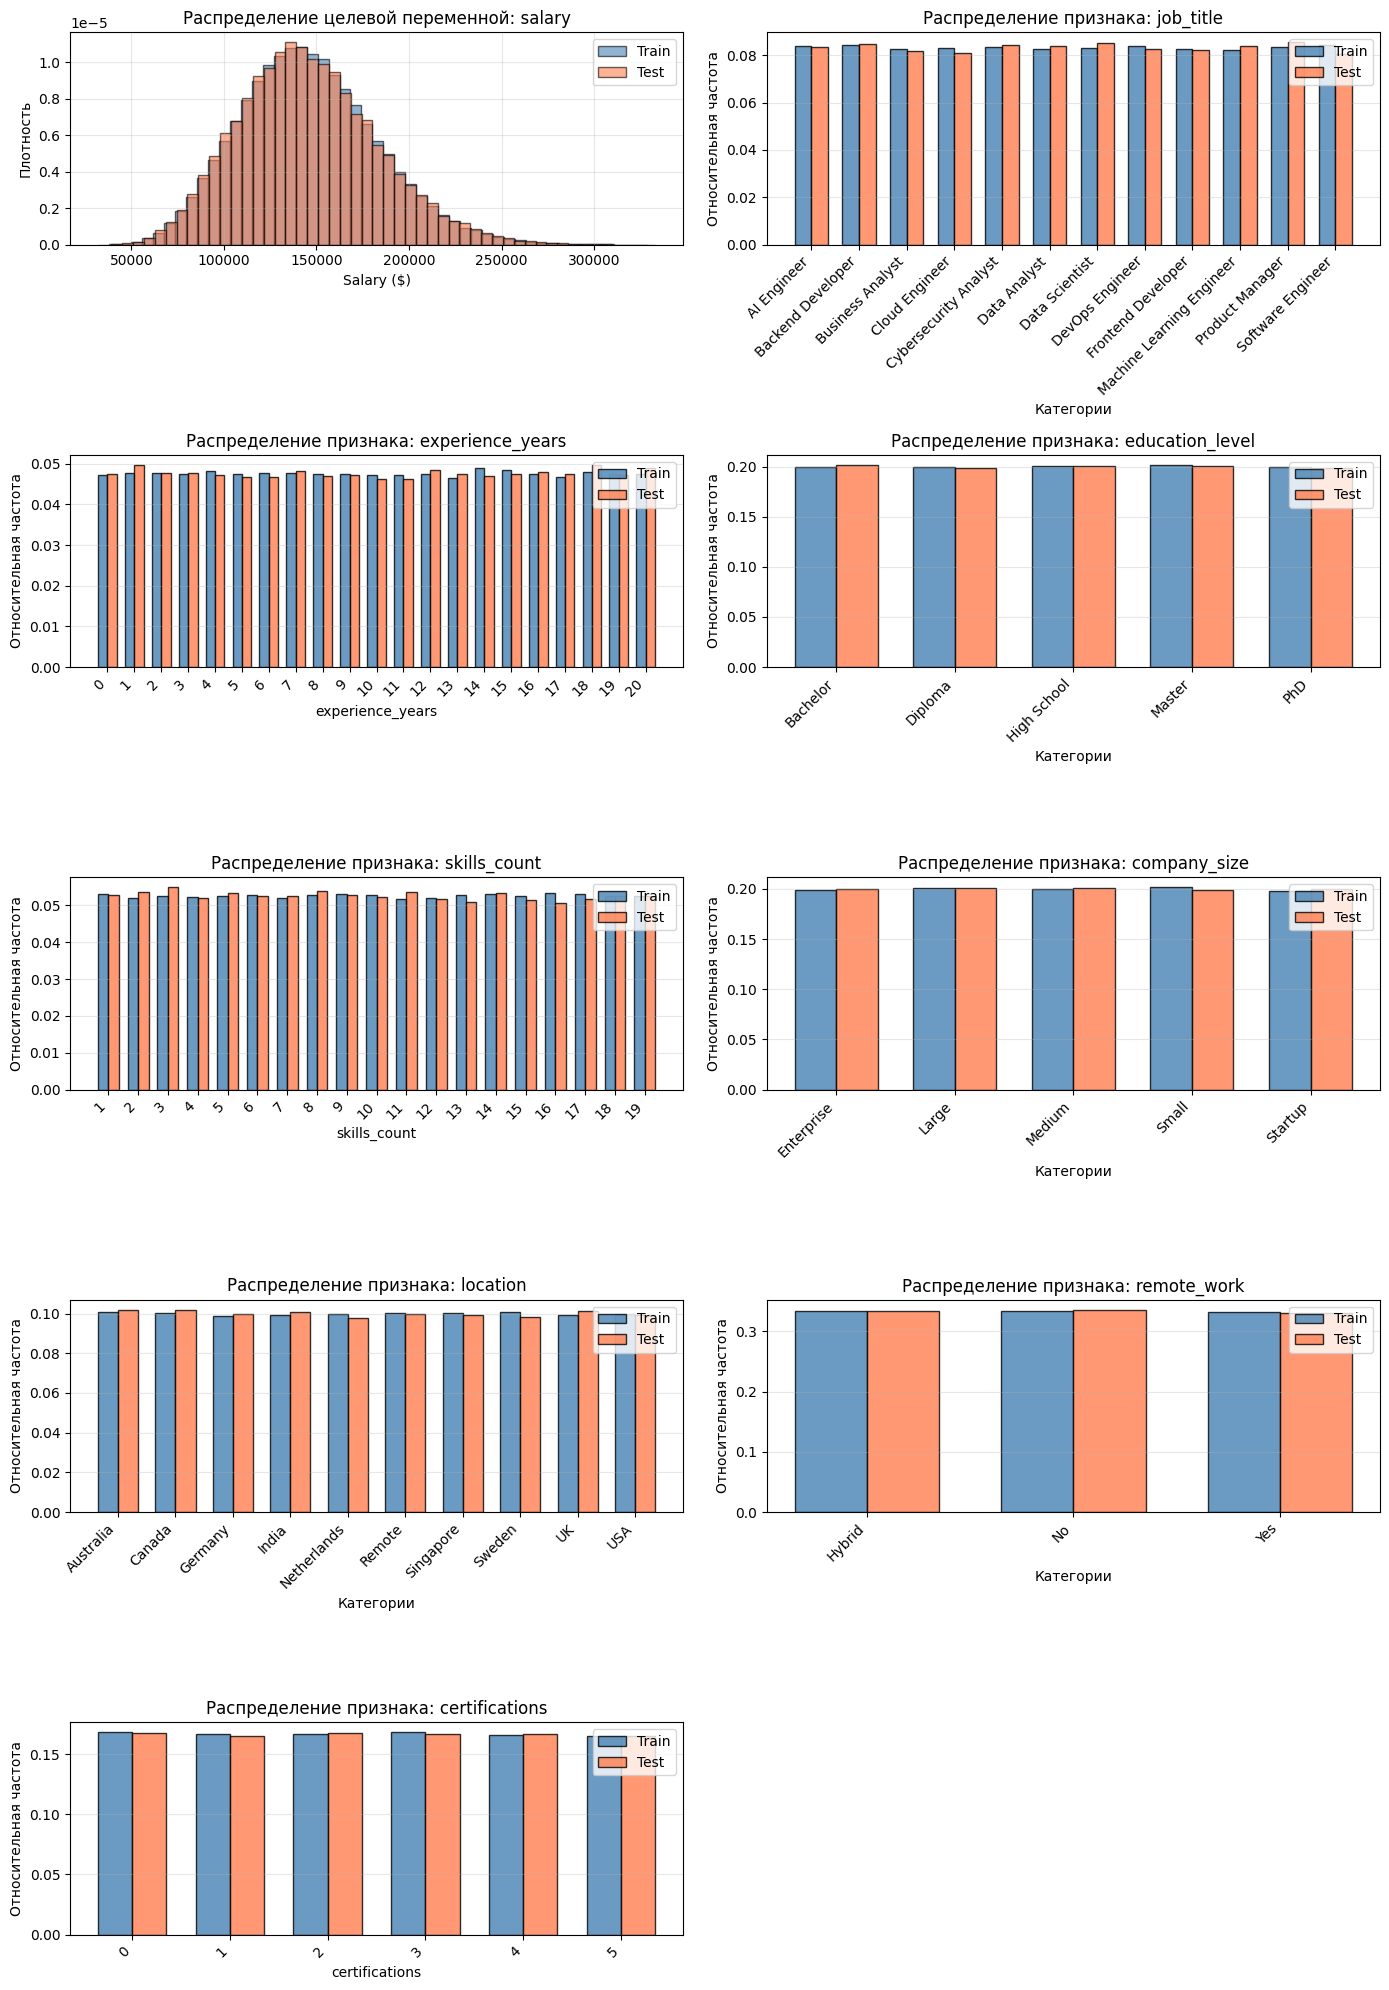

In [14]:
# Определяем список всех признаков (исключая целевую переменную)
all_features = X_train.columns.tolist()

# Определяем количество графиков: по одному на каждый признак + целевая переменная
n_plots = len(all_features) + 1
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

# Создаём фигуру с подграфиками
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Счётчик для индексации подграфиков
plot_idx = 0

# 1. Сравнение распределения целевой переменной salary (гистограмма для непрерывной переменной)
ax = axes[plot_idx]
ax.hist(y_train, bins=50, alpha=0.6, color='steelblue', edgecolor='black', label='Train', density=True)
ax.hist(y_test, bins=50, alpha=0.6, color='coral', edgecolor='black', label='Test', density=True)
ax.set_xlabel('Salary ($)')
ax.set_ylabel('Плотность')
ax.set_title('Распределение целевой переменной: salary')
ax.legend()
ax.grid(True, alpha=0.3)
plot_idx += 1

# 2. Сравнение распределения признаков
for feature in all_features:
    ax = axes[plot_idx]

    # Проверяем тип данных признака
    if X_train[feature].dtype in ['int64', 'float64']:
        # Для дискретных числовых признаков используем столбчатую диаграмму с относительными частотами,
        # так как гистограмма с делением по бинам может исказить распределение,
        # объединяя в один бин несколько уникальных значений

        # Подсчитываем относительные частоты для каждого уникального значения
        train_counts = X_train[feature].value_counts(normalize=True).sort_index()
        test_counts = X_test[feature].value_counts(normalize=True).sort_index()

        # Объединяем все уникальные значения из обеих выборок
        all_values = sorted(set(train_counts.index) | set(test_counts.index))

        # Выравниваем значения для построения grouped bar chart
        train_aligned = [train_counts.get(val, 0) for val in all_values]
        test_aligned = [test_counts.get(val, 0) for val in all_values]

        # Позиции для столбцов
        x = np.arange(len(all_values))
        width = 0.35

        # Строим столбчатую диаграмму с группировкой
        ax.bar(x - width/2, train_aligned, width, label='Train', alpha=0.8, color='steelblue', edgecolor='black')
        ax.bar(x + width/2, test_aligned, width, label='Test', alpha=0.8, color='coral', edgecolor='black')
        ax.set_xlabel(feature)
        ax.set_ylabel('Относительная частота')
        ax.set_title(f'Распределение признака: {feature}')
        ax.set_xticks(x)
        ax.set_xticklabels(all_values, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

    else:
        # Для категориальных признаков используем столбчатую диаграмму с относительными частотами
        train_counts = X_train[feature].value_counts(normalize=True)
        test_counts = X_test[feature].value_counts(normalize=True)

        # Объединяем все категории
        all_categories = sorted(set(train_counts.index) | set(test_counts.index))
        train_aligned = [train_counts.get(cat, 0) for cat in all_categories]
        test_aligned = [test_counts.get(cat, 0) for cat in all_categories]

        # Позиции для столбцов
        x = np.arange(len(all_categories))
        width = 0.35

        # Строим столбчатую диаграмму с группировкой
        ax.bar(x - width/2, train_aligned, width, label='Train', alpha=0.8, color='steelblue', edgecolor='black')
        ax.bar(x + width/2, test_aligned, width, label='Test', alpha=0.8, color='coral', edgecolor='black')
        ax.set_xlabel('Категории')
        ax.set_ylabel('Относительная частота')
        ax.set_title(f'Распределение признака: {feature}')
        ax.set_xticks(x)
        ax.set_xticklabels(all_categories, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

    plot_idx += 1

# Скрываем неиспользуемые подграфики
for idx in range(plot_idx, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

**Вывод:** **Распределения всех переменных в тренировочной и тестовой выборках демонстрируют высокую степень схожести и полную сопоставимость**.

## **Предобработка признаков перед подачей в модель**

### **Кодирование категориальных признаков**

**Линейная регрессия требует числового формата всех входных данных, поэтому категориальные признаки необходимо закодировать в числовой вид**. Поскольку в датасете присутствуют как порядковые, так и номинальные категориальные переменные, для каждой группы применяется соответствующий метод кодирования. **Для порядковых признаков education_level и company_size, где уровни образования (High School → Diploma → Bachelor → Master → PhD) и размеры компаний (Startup → Small → Medium → Large → Enterprise) обладают естественной иерархией, используется Ordinal Encoding**, позволяющий сохранить порядковую структуру данных. **Для номинальных признаков с невысокой кардинальностью - remote_work (3 уникальных значения), location (10 уникальных значений) и job_title (12 уникальных значений) - применяется One-Hot Encoding**, который создаёт отдельные бинарные признаки для каждой категории. При этом используется параметр drop='first', что позволяет избежать мультиколлинеарности (ситуации, когда один признак линейно выражается через комбинацию других) и сократить количество создаваемых признаков на один столбец на каждую категориальную переменную без потери информативности.

### **Масштабирование числовых признаков**

**Для линейной регрессии необходимо выполнить масштабирование числовых признаков**, поскольку это обеспечивает более быструю сходимость алгоритма и позволяет интерпретировать важность признаков по величине их коэффициентов. Хотя диапазоны значений признаков experience_years (0–20), skills_count (1–19) и certifications (0–5) кажутся близкими, разница в масштабах всё же присутствует - например, диапазон experience_years в 4 раза шире диапазона certifications, что без масштабирования привело бы к искажению сравнительной значимости признаков. **Для числовых признаков применяется стандартизация (StandardScaler), которая предпочтительнее для линейной регрессии**, чем нормализация (MinMaxScaler).

## **Создание Pipeline для предобработки и моделирования**

**Создадим Pipeline, который объединяет предобработку признаков** (масштабирование числовых переменных, порядковое и one-hot кодирование категорий) **с созданием экземпляра модели линейной регрессии**. Pipeline предотвращает утечку данных, поскольку параметры преобразований вычисляются исключительно на обучающей выборке и затем применяются к тестовой, что исключает использование информации из тестовых данных при настройке предобработки, а также автоматизирует процесс обучения и предсказания.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression

# Определяем группы признаков
numerical_features = ['experience_years', 'skills_count', 'certifications']
categorical_ordinal = ['education_level', 'company_size']
categorical_nominal = ['job_title', 'location', 'remote_work']

# Задаём порядок для порядковых признаков
education_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
company_size_order = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']

# Создаём препроцессор с помощью ColumnTransformer
# Он применяет разные преобразования к разным группам признаков
preprocessor = ColumnTransformer(
    transformers=[
        # Стандартизация для числовых признаков
        ('num', StandardScaler(), numerical_features),

        # OrdinalEncoding для порядковых признаков
        ('ord', OrdinalEncoder(categories=[education_order, company_size_order]),
         categorical_ordinal),

        # One-HotEncoding для номинальных признаков
        ('nom', OneHotEncoder(drop='first', sparse_output=False),
         categorical_nominal)
    ]
)

# Создаём полный пайплайн: сначала предобработка признаков, затем создание экземпляра модели линейной регрессии
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), ('regression', LinearRegression())
])

## **Обучение модели и получение предсказаний с использованием Pipeline**

In [16]:
# Обучаем пайплайн на тренировочных данных
# Pipeline автоматически:
# 1) Применяет предобработку к X_train (масштабирование, кодирование)
# 2) Обучает модель LinearRegression на преобразованных данных
model_pipeline.fit(X_train, y_train)

# Получаем предсказания с помощью обученного пайплайна
# Pipeline автоматически:
# 1) Применяет предобработку к тестовым данным с параметрами из train
# 2) Предсказывает на преобразованных тестовых данных
y_test_pred = model_pipeline.predict(X_test)

## **Создание модели константного предсказания (Dummy Regressor)**

**Создадим модель константного предсказания, которая всегда возвращает медиану целевой переменной из обучающей выборки**, игнорируя входные признаки. Это необходимо **для получения базового уровня качества, с которым можно сравнить обученную модель линейной регрессии**.

In [17]:
from sklearn.dummy import DummyRegressor

# Создаем модель константного предсказания со стратегией 'median'
# Модель всегда предсказывает медиану целевой переменной из обучающей выборки
dummy_model = DummyRegressor(strategy='median')

# Обучаем модель на тренировочных данных
dummy_model.fit(X_train, y_train)

# Получаем предсказания на тестовой выборке
# Модель возвращает медиану y_train для всех записей тестовой выборки
y_test_pred_dummy = dummy_model.predict(X_test)

## **Оценка качества моделей линейной регрессии и константного предсказания**

**Для оценки качества моделей** линейной регрессии и константного предсказания **используются две метрики**: **средняя абсолютная ошибка (MAE)**, которая показывает среднее отклонение предсказанных значений от реальных в долларах США, и **коэффициент детерминации (R²)**, отражающий долю дисперсии целевой переменной, объяснённую моделью. Произведённая оценка позволит не только измерить качество каждой модели изолированно, но и сравнить линейную регрессию с базовым уровнем качества, представленным константным предсказанием медианы, чтобы определить, насколько обученная модель лучше простейшего подхода.

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

# Оценка качества модели линейной регрессии
print('Оценка качества модели линейной регрессии:')
print(f'MAE: {mean_absolute_error(y_test, y_test_pred):.0f}')
print(f'R²: {r2_score(y_test, y_test_pred):.4f}')

# Оценка качества константной модели
print('\nОценка качества константной модели:')
print(f'MAE: {mean_absolute_error(y_test, y_test_pred_dummy):.0f}')
print(f'R²: {r2_score(y_test, y_test_pred_dummy):.4f}')

Оценка качества модели линейной регрессии:
MAE: 6110
R²: 0.9554

Оценка качества константной модели:
MAE: 29896
R²: -0.0035


**Константная модель**, которая всегда выдаёт в качестве предсказания медиану зарплат из обучающей выборки, даёт MAE = 29 896 долларов. Это означает, что в среднем прогнозы модели отклоняются от реальных значений на 29 896 долларов, что является неприемлемо высоким показателем для задачи прогнозирования зарплат. Отрицательный коэффициент детерминации (R² = -0,0035) указывает на то, что модель не объясняет дисперсию целевой переменной и работает хуже, чем простое предсказание средним значением. Это свидетельствует о полной непригодности модели для прогнозирования.

**Модель линейной регрессии** показывает MAE = 6 110 долларов, что означает, что в среднем прогнозы модели отклоняются от реальных значений на 6 110 долларов. Это значение в 4,89 раза ниже ошибки константной модели. Коэффициент детерминации R² = 0,9554 показывает, что модель объясняет 95,54% вариации зарплат, существенно превосходя предсказание средним значением (R² = 0). Такой результат свидетельствует об отличном качестве прогнозов и высокой предсказательной силе модели.

Сравнивая две модели, можно уверенно заключить, что **линейная регрессия значительно превосходит константное предсказание**. Она снижает среднюю абсолютную ошибку на 23 786 долларов, что соответствует улучшению на 79,6%, и объясняет практически всю вариативность зарплат, тогда как константная модель не даёт никакой прогностической ценности.

Таким образом, **модель линейной регрессии демонстрирует высокое качество, обладает высокой прогностической ценностью и может быть использована для прогнозирования заработных плат сотрудников**.